# Comparison: MDA vs K-Means

This notebook compares two methods for reducing a large multivariate dataset to representative cases: the **Maximum Dissimilarity Algorithm (MDA)** and the **K-Means Algorithm (KMA)** implemented in `bluemath_tk`.

Both methods return centroids, but optimize different objectives: MDA prioritizes coverage and extremes, whereas K-Means minimizes the average distance within clusters and therefore represents dense regions more strongly.

In [1]:
import numpy as np
import pandas as pd
from bluemath_tk.datamining.kma import KMA
from bluemath_tk.datamining.lhs import LHS
from bluemath_tk.datamining.mda import MDA
from utils.plotting import plot_variable_combinations

## 1. Generate the candidate dataset

The examples use significant wave height ($H_s$), peak period ($T_p$), and wave direction ($Dir$). Direction is circular, so values close to $0^\circ$ and $360^\circ$ must be treated as neighbors.

### Option A: independent random values

This cell illustrates simple independent random sampling. Each variable is drawn separately, so the resulting design has no physical relationships and may contain local gaps or clusters.

> The following LHS cell assigns a new value to `data`; consequently, the MDA and K-Means comparison below uses the LHS dataset rather than this random dataset.

In [2]:
data = pd.DataFrame(
    {
        "Hs": np.random.rand(1000) * 7,
        "Tp": np.random.rand(1000) * 20,
        "Dir": np.random.rand(1000) * 360,
    }
)

### Option B: Latin Hypercube Sampling (used below)

LHS stratifies every variable range to produce more uniform multidimensional coverage than independent random sampling.

- `num_dimensions`: number of variables sampled together.
- `seed`: makes the design reproducible.
- `dimensions_names`: output column names, ordered consistently with the bounds.
- `lower_bounds` and `upper_bounds`: permitted interval for every variable.
- `num_samples`: number of complete combinations generated.

`generate` returns the `DataFrame` used by both selection algorithms.

In [3]:
dimensions_names = ["Hs", "Tp", "Dir"]
lower_bounds = [0, 3, 0]
upper_bounds = [7, 20, 360]
num_samples = 1000

lhs = LHS(num_dimensions=len(dimensions_names), seed=0)
data = lhs.generate(
    dimensions_names=dimensions_names,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    num_samples=num_samples,
)
data

,Hs,Tp,Dir
0,5.511541,17.343414,231.825250
1,5.732884,6.233174,32.791408
2,4.307754,5.027599,26.444295
3,0.903454,9.463130,221.039014
4,0.483998,15.545429,202.057324
...,...,...,...
995,6.867241,12.195831,341.955403
996,3.444233,6.485844,354.479253
997,2.211280,5.080653,9.562285
998,0.392336,5.479818,123.199842


## 2. Maximum Dissimilarity Algorithm (MDA)

MDA starts from one case and repeatedly selects the candidate whose minimum distance to the existing centroids is greatest. It tends to preserve domain boundaries and uncommon extremes.

### Arguments used

- `num_centers`: number of representative cases retained by `MDA`. This example selects 100.
- `data`: complete candidate table passed to `fit_predict`.
- `directional_variables`: angular columns handled through circular distance. `Dir` is included so north-facing values on either side of $0^\circ$ remain close.

`fit_predict` returns the nearest-centroid index and values for every original row. The unique selected cases are available in `mda.centroids`.

In [4]:
num_centers = 100
dir_vars = ["Dir"]

mda = MDA(num_centers=num_centers)
nearest_centroids_idxs, nearest_centroids_df = mda.fit_predict(
    data=data,
    directional_variables=dir_vars,
)

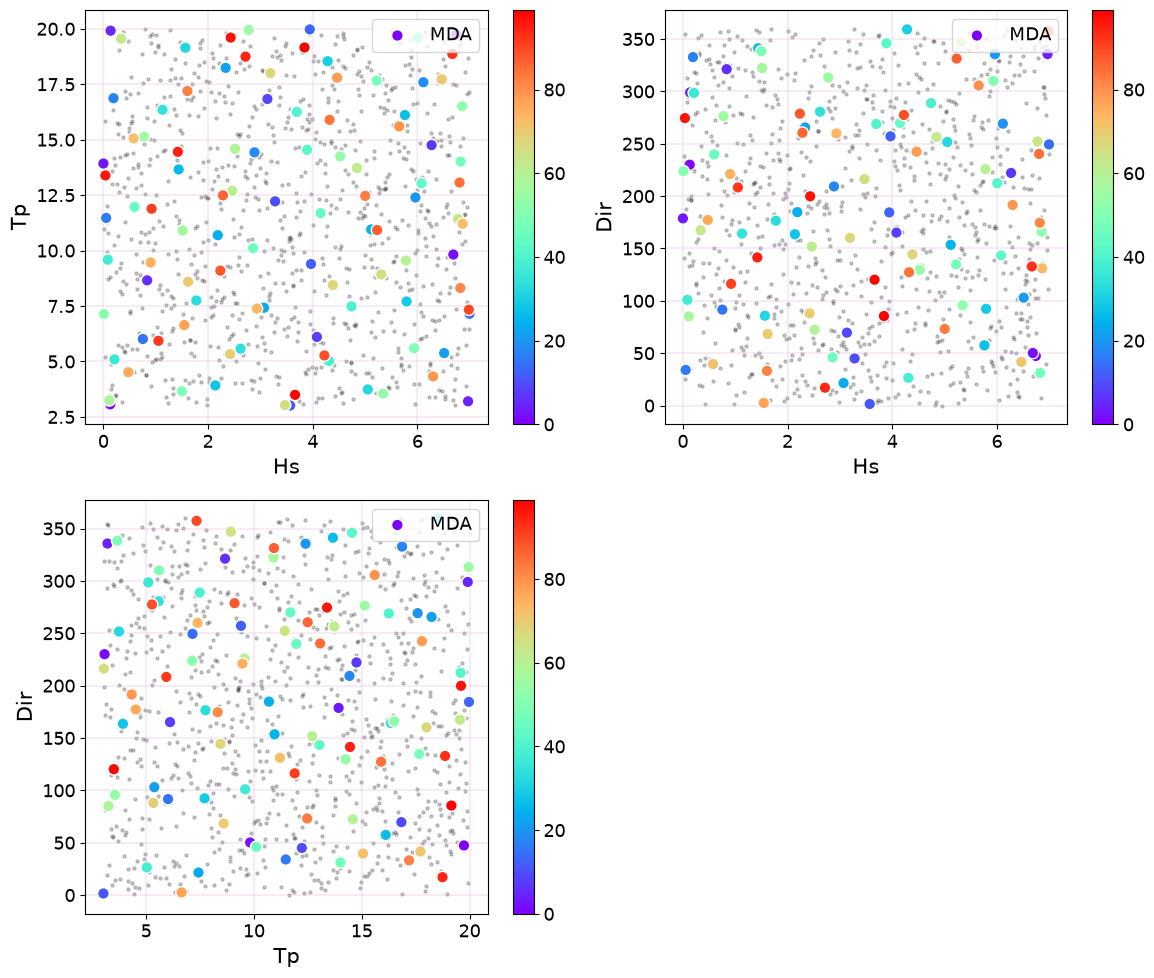

In [5]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(mda.data, vars, mda.centroids, labels="MDA")

## 3. K-Means Algorithm (KMA)

K-Means alternates between assigning each observation to its nearest centroid and updating each centroid to the mean of its cluster. It minimizes within-cluster squared distance and therefore emphasizes regions containing many observations.

### Arguments used

- `num_clusters`: number of groups and centroids calculated by `KMA`. This example uses 50.
- `data`: the same LHS table used by MDA.
- `directional_variables`: angular inputs transformed internally into circular components.

Useful optional arguments include `normalize_data`, `custom_scale_factor`, and `min_number_of_points`. `fit_predict` returns cluster assignments and the nearest centroid for every input row; unique centroids are stored in `kma.centroids`.

> MDA uses 100 centroids here while K-Means uses 50. For a strict performance comparison, set both values equal; the current plot primarily illustrates their different spatial behavior.

In [6]:
num_centers = 50
dir_vars = ["Dir"]

kma = KMA(num_clusters=num_centers)
nearest_centroids_idxs, nearest_centroids_df = kma.fit_predict(
    data=data,
    directional_variables=dir_vars,
)

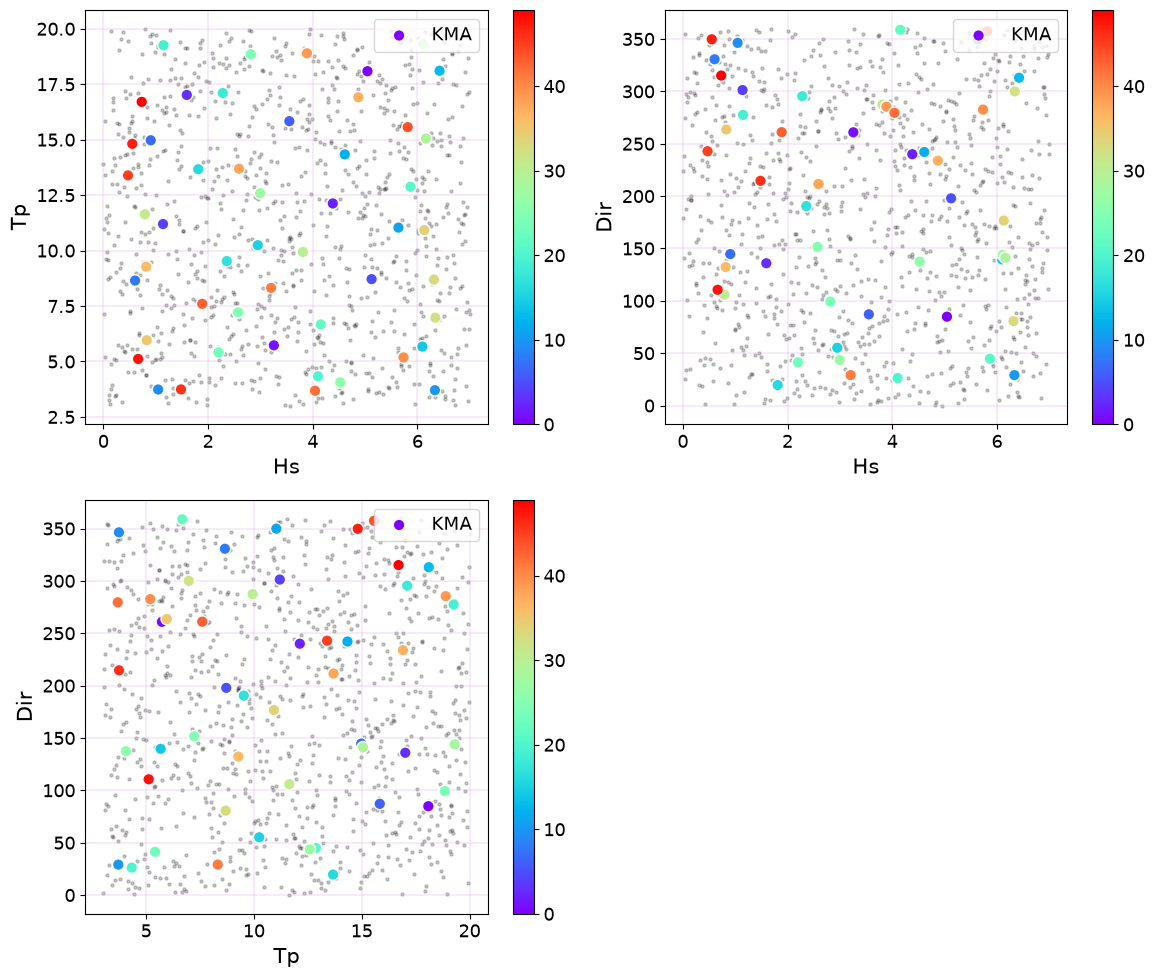

In [7]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
plot_variable_combinations(kma.data, vars, kma.centroids, labels="KMA")

## 4. Compare the selected centroids

The pairwise plots overlay both representative sets on the same candidate data. MDA centroids should spread toward the limits of the sampled domain, while K-Means centroids should follow the density of observations.

The variables are passed in the same order to every dataset. `labels=["MDA", "KMA"]` identifies the two centroid collections in the legend.

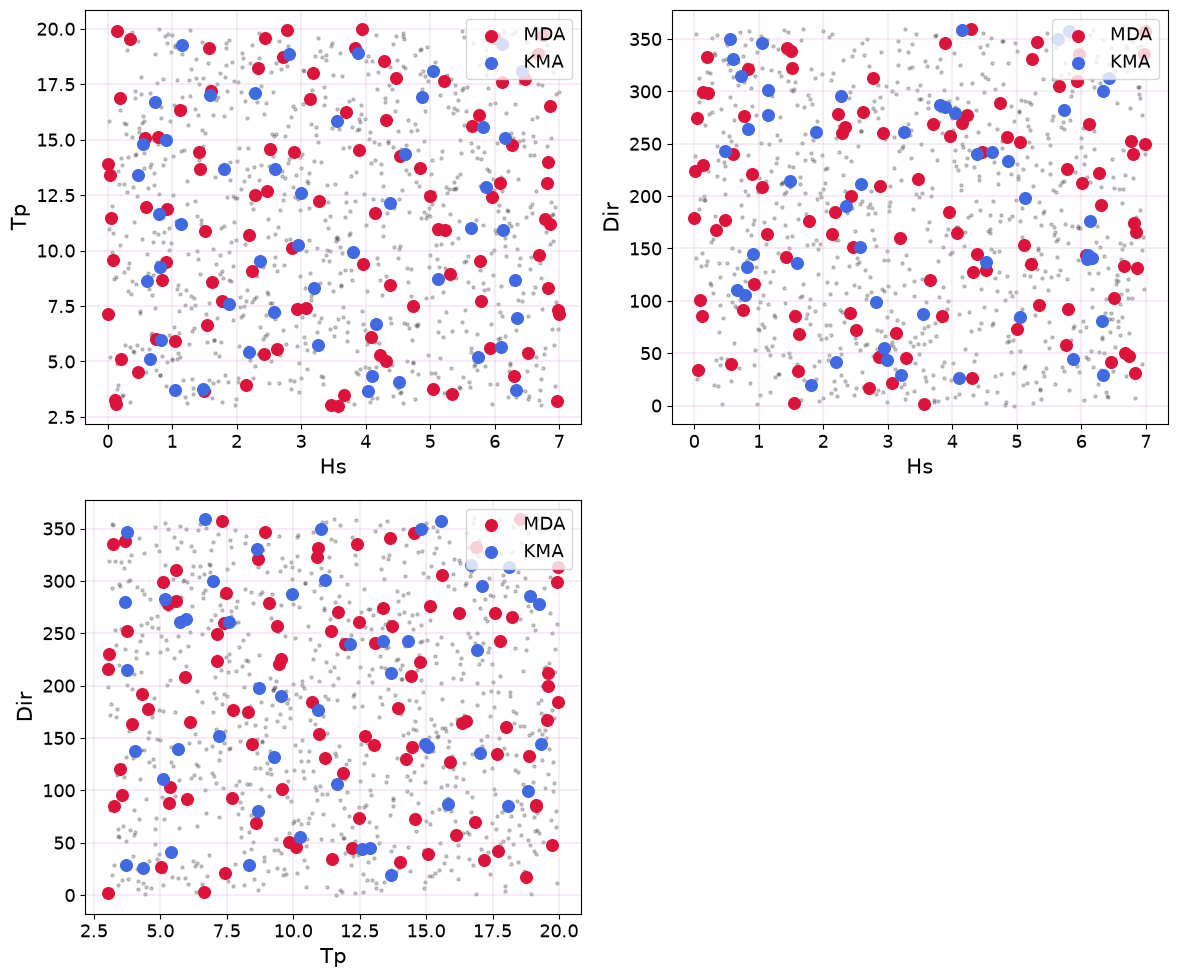

In [8]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(
    mda.data, vars, [mda.centroids, kma.centroids], labels=["MDA", "KMA"]
)

## 5. Assign new observations

The fitted models can assign new sea states without recalculating their centroids. `data_pred` must contain the same variables, names, and units used during fitting. The three cases include directions near different parts of the circular domain.

In [9]:
# Generate a sample data to predict:

data_pred = pd.DataFrame({"Hs": [4, 2, 6], "Tp": [12, 10, 15], "Dir": [90, 350, 280]})

### Assignment with MDA

`mda.predict(data_pred)` returns the nearest MDA centroid index and its values for every new row. Indexing `mda.centroids` with the first result displays the representative cases selected directly from the original dataset.

In [10]:
print("\nInput data to predict:")
print(data_pred)

print("\nPredicted Cluster:")
print(mda.centroids.iloc[mda.predict(data_pred)[0]])


Input data to predict:
   Hs  Tp  Dir
0   4  12   90
1   2  10  350
2   6  15  280

Predicted Cluster:
          Hs         Tp     Dir_u     Dir_v         Dir
10  3.280023  12.220456  0.707129  0.707085   45.001765
57  1.513513  10.904877 -0.611003  0.791628  322.337952
80  5.650789  15.599518 -0.813203  0.581981  305.589985


### Assignment with K-Means

`kma.predict(data_pred)` returns cluster membership information and the corresponding nearest centroid values. `kma_bmus` contains the cluster identifiers used to select rows from `kma.centroids`. Unlike MDA representatives, K-Means centroids are averages and may not coincide with actual observations.

In [11]:
print("\nInput data to predict:")
print(data_pred)

print("\nPredicted Cluster:")
print(kma.centroids.iloc[kma.predict(data_pred)[0].kma_bmus.values])


Input data to predict:
   Hs  Tp  Dir
0   4  12   90
1   2  10  350
2   6  15  280

Predicted Cluster:
          Hs         Tp    Dir_u     Dir_v         Dir
27  2.994793  12.586271  0.54342  0.570195   43.622684
15  2.948858  10.243050  0.70803  0.492026   55.203694
44  5.813040  15.565484 -0.03786  0.838637  357.415126


## Summary

MDA and K-Means both reduce the candidate dataset to representative cases, but they answer different questions:

- Choose **MDA** when domain coverage, boundaries, and rare extremes are important.
- Choose **K-Means** when the goal is to represent the probability density and minimize average within-cluster error.

For a quantitative comparison, both algorithms should use the same number of centroids and be evaluated with a metric aligned with the final application.